In [1]:
import os
import re
import csv


# Setup

In [2]:
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_04_wholetest/"
new_results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_08_wholeTests/"

DNA_result="100taxa_dataset"
AA_result=f"{DNA_result}_AA"

output_csv = "results.csv"
output_csv_aa=f"{output_csv}_AA"

In [3]:
# Regex to capture the RESULT line
pattern = re.compile(
    r"\[RESULT\]\s*backend=(\w+)\s+taxa=(\d+)\s+sites=(\d+)\s+patterns=(\d+)\s+time=([\d\.e\+\-]+)s\s+likelihood=([\-.\deE]+)"
)


In [4]:
lengths = [100, 1000, 10000, 100000, 1000000]

In [5]:
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
likelihood_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took \d+ rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

# Distribution & Min-value Analysis (DNA + AA)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def collect_all_data(old_results_path, new_results_path, folder_name, lengths):
    """
    Collect all results using:
      - POC .txt (PROTOTYPE_GPU) from old path
      - IQ-TREE CPU (1CPU, 10CPU, 48CPU) from old path
      - IQ-TREE GPU (OpenACC) from new path where available, fallback to old path
    """
    all_data = []
    
    for length in lengths:
        old_dir = f"{old_results_path}/{folder_name}/alignment_{length}"
        new_dir = f"{new_results_path}/{folder_name}/alignment_{length}"
        
        if not os.path.exists(old_dir):
            print(f"Skipping {old_dir} (not found)")
            continue
        
        old_files = os.listdir(old_dir)
        
        # 1) POC OpenACC (.txt files) from OLD path
        for file in old_files:
            if file.endswith('.txt') and 'openACC' in file:
                filepath = f'{old_dir}/{file}'
                with open(filepath, 'r') as f:
                    for line in f:
                        match = pattern.search(line)
                        if match:
                            _, taxa, sites, patterns, time_val, likelihood = match.groups()
                            if taxa != "100":
                                continue
                            all_data.append(['PROTOTYPE_GPU_V100', int(taxa), int(sites), 
                                           int(patterns), float(likelihood), float(time_val)])
        
        # 2) IQ-TREE CPU (1CPU, 10CPU, 48CPU) from OLD path
        for file in old_files:
            if not file.endswith('.log'):
                continue
            parts = file.split("_")
            backend_raw = parts[2]
            
            if "48CPU" in backend_raw:
                backend = "IQ-TREE_CPU_48threads"
            elif "10CPU" in backend_raw:
                backend = "IQ-TREE_CPU_10threads"
            elif "1CPU" in backend_raw:
                backend = "IQ-TREE_CPU"
            else:
                continue  # skip OpenACC from old path
            
            filepath = f'{old_dir}/{file}'
            with open(filepath, 'r') as f:
                content = f.read()
            
            aln_match = alignment_pattern.search(content)
            ll_match = likelihood_pattern.search(content)
            opt_match = params_opt_pattern.search(content)
            
            if aln_match and ll_match and opt_match:
                taxa = int(aln_match.group(1))
                sites = int(aln_match.group(2))
                patterns = int(aln_match.group(3))
                likelihood = float(ll_match.group(1))
                time_val = float(opt_match.group(1))
                all_data.append([backend, taxa, sites, patterns, likelihood, time_val])
        
        # 3) IQ-TREE GPU (OpenACC) from NEW path if available, else OLD path
        gpu_found_in_new = False
        if os.path.exists(new_dir):
            new_files = os.listdir(new_dir)
            new_logs = [f for f in new_files if f.endswith('.log') and 'wholesTest' in f]
            if new_logs:
                gpu_found_in_new = True
                for file in new_logs:
                    filepath = f'{new_dir}/{file}'
                    with open(filepath, 'r') as f:
                        content = f.read()
                    
                    aln_match = alignment_pattern.search(content)
                    ll_match = likelihood_pattern.search(content)
                    opt_match = params_opt_pattern.search(content)
                    
                    if aln_match and ll_match and opt_match:
                        taxa = int(aln_match.group(1))
                        sites = int(aln_match.group(2))
                        patterns = int(aln_match.group(3))
                        likelihood = float(ll_match.group(1))
                        time_val = float(opt_match.group(1))
                        all_data.append(["IQ-TREE_GPU", taxa, sites, patterns, likelihood, time_val])
        
        if not gpu_found_in_new:
            # Fallback to old path OpenACC
            for file in old_files:
                if not file.endswith('.log'):
                    continue
                parts = file.split("_")
                backend_raw = parts[2]
                if "OpenACC" not in backend_raw:
                    continue
                
                filepath = f'{old_dir}/{file}'
                with open(filepath, 'r') as f:
                    content = f.read()
                
                aln_match = alignment_pattern.search(content)
                ll_match = likelihood_pattern.search(content)
                opt_match = params_opt_pattern.search(content)
                
                if aln_match and ll_match and opt_match:
                    taxa = int(aln_match.group(1))
                    sites = int(aln_match.group(2))
                    patterns = int(aln_match.group(3))
                    likelihood = float(ll_match.group(1))
                    time_val = float(opt_match.group(1))
                    all_data.append(["IQ-TREE_GPU", taxa, sites, patterns, likelihood, time_val])
    
    df = pd.DataFrame(all_data, columns=['backend', 'taxa', 'sites', 'patterns', 'likelihood', 'time'])
    print(f"Collected {len(df)} results across {df['backend'].nunique()} backends")
    print(df.groupby(['backend', 'sites']).size().unstack(fill_value=0))
    return df

In [7]:
# Collect DNA and AA data separately
# IQ-TREE GPU (OpenACC) from new_results_path, everything else from results_path
df_dna = collect_all_data(results_path, new_results_path, DNA_result, lengths)
df_aa = collect_all_data(results_path, new_results_path, AA_result, lengths)

Collected 250 results across 5 backends
sites                  100      1000     10000    100000   1000000
backend                                                           
IQ-TREE_CPU                 10       10       10       10       10
IQ-TREE_CPU_10threads       10       10       10       10       10
IQ-TREE_CPU_48threads       10       10       10       10       10
IQ-TREE_GPU                 10       10       10       10       10
PROTOTYPE_GPU_V100          10       10       10       10       10
Collected 250 results across 5 backends
sites                  100      1000     10000    100000   1000000
backend                                                           
IQ-TREE_CPU                 10       10       10       10       10
IQ-TREE_CPU_10threads       10       10       10       10       10
IQ-TREE_CPU_48threads       10       10       10       10       10
IQ-TREE_GPU                 10       10       10       10       10
PROTOTYPE_GPU_V100          10       10       10 

In [8]:
import seaborn as sns

BACKEND_COLORS = {
    'IQ-TREE_CPU':            '#1565C0',  # blue
    'PROTOTYPE_GPU_V100':     '#F9A825',  # amber/orange
    'IQ-TREE_CPU_10threads':  '#757575',  # gray
    'IQ-TREE_CPU_48threads':  '#2E7D32',  # green
    'IQ-TREE_GPU':            '#E65100',  # deep orange
}

SITE_LABELS = {
    100: '100', 1000: '1k', 10000: '10k',
    100000: '100k', 1000000: '1M', 10000000: '10M',
}


def _plot_on_axis(ax, df, title, show_distribution=True):
    """Plot wall-time vs sites on a given matplotlib axis."""
    sites_order = sorted(df['sites'].unique())

    for backend in sorted(df['backend'].unique()):
        bdata = df[df['backend'] == backend]
        color = BACKEND_COLORS.get(backend, None)

        medians, mins, maxs = [], [], []
        valid_sites = []

        for sites in sites_order:
            sdata = bdata[bdata['sites'] == sites]['time']
            if len(sdata) == 0:
                continue
            valid_sites.append(sites)
            medians.append(sdata.median())
            mins.append(sdata.min())
            maxs.append(sdata.max())

        if not valid_sites:
            continue

        if show_distribution:
            # Shaded band from min to max
            ax.fill_between(valid_sites, mins, maxs, alpha=0.15, color=color)
            ax.plot(valid_sites, medians, marker='o', color=color,
                    label=backend, linewidth=2, markersize=5)
            y_end = medians[-1]
        else:
            ax.plot(valid_sites, mins, marker='o', color=color,
                    label=backend, linewidth=2, markersize=5)
            y_end = mins[-1]

        # Label at the end of each line
        ax.annotate(backend, xy=(valid_sites[-1], y_end),
                    xytext=(10, 0), textcoords='offset points',
                    color=color, fontweight='bold', va='center', fontsize=9)

    ax.set_xscale('log')
    ax.set_xticks(sites_order)
    ax.set_xticklabels([SITE_LABELS.get(s, str(s)) for s in sites_order])
    ax.minorticks_off()
    ax.set_xlabel('Number of Sites')
    ax.set_ylabel('Runtime (s)')
    ax.set_title(title)

    # Expand right margin for labels
    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0], xlim[1] * 3)

    ax.grid(True, which="major", ls="--", alpha=0.5)


def plot_walltime_single(df, title="Wall-time vs Number of sites for 100 taxa",
                         path="", show_distribution=True):
    """Single plot for one data type."""
    fig, ax = plt.subplots(figsize=(10, 7))
    _plot_on_axis(ax, df, title, show_distribution)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_walltime_sidebyside(df_dna, df_aa,
                              title="Wall-time vs Number of sites for 100 taxa",
                              path="", show_distribution=True):
    """Side-by-side DNA and AA plots (matching reference image layout)."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

    _plot_on_axis(ax1, df_dna, title, show_distribution)
    _plot_on_axis(ax2, df_aa, title, show_distribution)

    # Subtitles below each plot
    ax1.text(0.5, -0.10, "For DNA alignments", transform=ax1.transAxes,
             ha='center', fontsize=13, style='italic')
    ax2.text(0.5, -0.10, "For AA alignments", transform=ax2.transAxes,
             ha='center', fontsize=13, style='italic')

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_min_walltime(df, title="Min Wall-time vs Number of sites for 100 taxa", path=""):
    """Plot only the minimum time from 10 runs per backend per site count."""
    fig, ax = plt.subplots(figsize=(10, 7))
    sites_order = sorted(df['sites'].unique())

    # Compute min per backend per site count
    df_min = df.groupby(['backend', 'sites'])['time'].min().reset_index()

    for backend in sorted(df_min['backend'].unique()):
        bdata = df_min[df_min['backend'] == backend].sort_values('sites')
        color = BACKEND_COLORS.get(backend, None)

        ax.plot(bdata['sites'], bdata['time'], marker='o', color=color,
                label=backend, linewidth=2, markersize=6)

        # Label at end of line
        ax.annotate(backend, xy=(bdata['sites'].iloc[-1], bdata['time'].iloc[-1]),
                    xytext=(10, 0), textcoords='offset points',
                    color=color, fontweight='bold', va='center', fontsize=9)

    ax.set_xscale('log')
    ax.set_xticks(sites_order)
    ax.set_xticklabels([SITE_LABELS.get(s, str(s)) for s in sites_order])
    ax.minorticks_off()
    ax.set_xlabel('Number of Sites')
    ax.set_ylabel('Runtime (s)')
    ax.set_title(title)

    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0], xlim[1] * 3)

    ax.grid(True, which="major", ls="--", alpha=0.5)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()

## Distribution plots (shaded band = min–max spread across 10 runs, line = median)

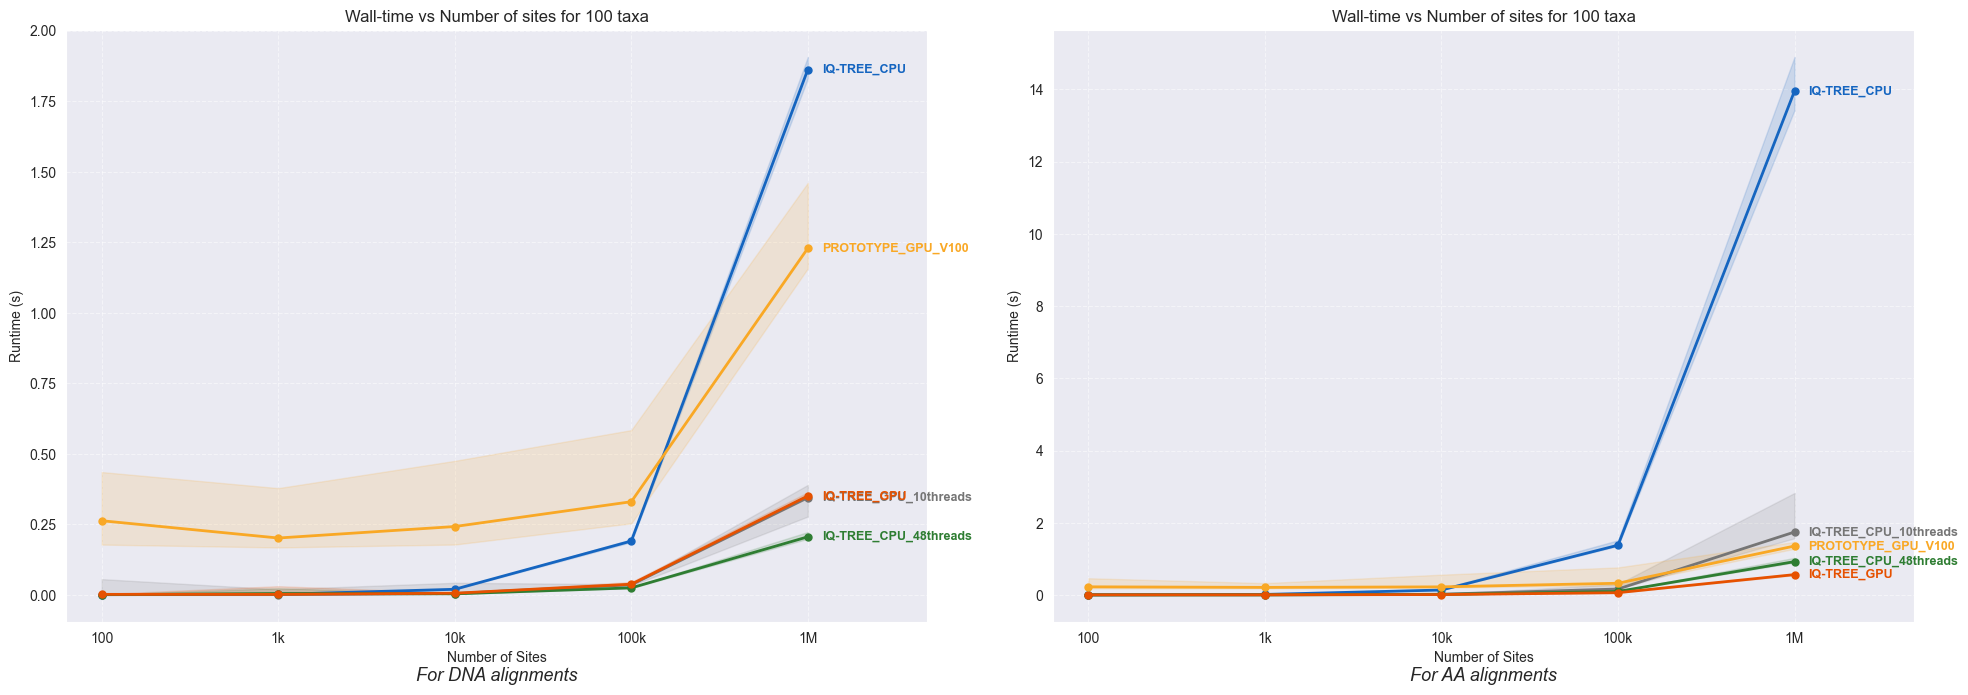

In [9]:
cwd = os.getcwd()

# Side-by-side distribution plot
plot_walltime_sidebyside(df_dna, df_aa,
                          title="Wall-time vs Number of sites for 100 taxa",
                          path=f"{cwd}/walltime_distribution_sidebyside.png",
                          show_distribution=True)

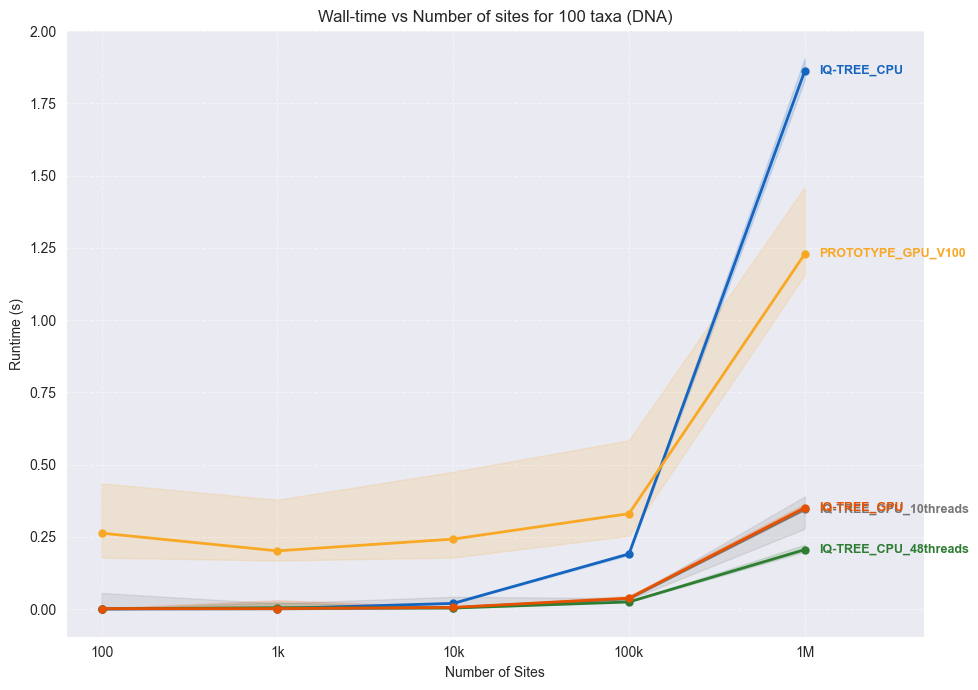

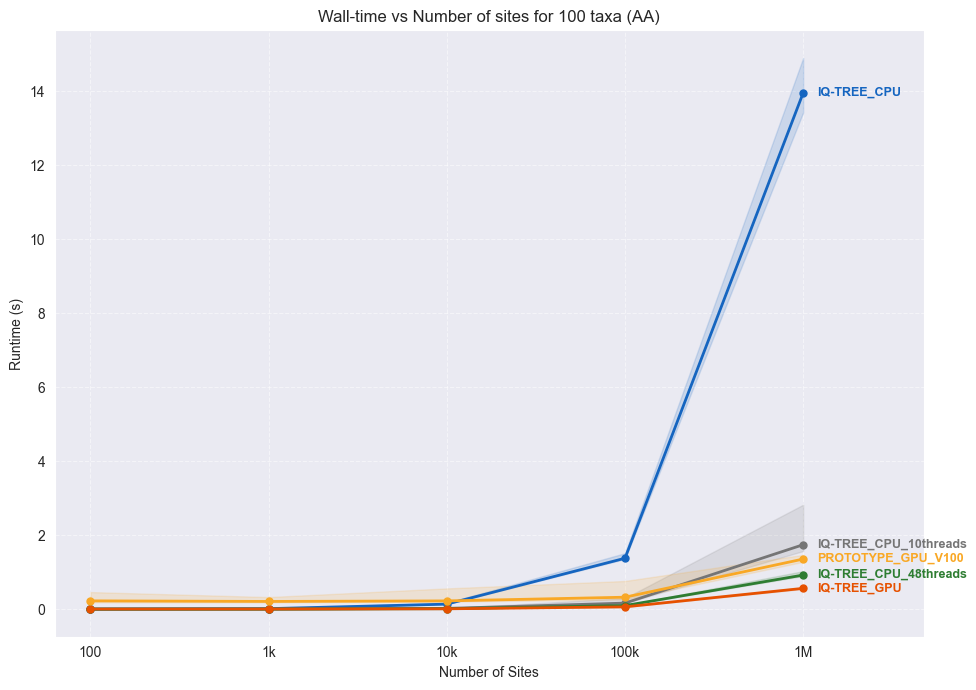

In [10]:
# Individual distribution plots
plot_walltime_single(df_dna,
                     title="Wall-time vs Number of sites for 100 taxa (DNA)",
                     path=f"{cwd}/walltime_dna_distribution.png",
                     show_distribution=True)

plot_walltime_single(df_aa,
                     title="Wall-time vs Number of sites for 100 taxa (AA)",
                     path=f"{cwd}/walltime_aa_distribution.png",
                     show_distribution=True)

## Min-value only plots (dedicated `plot_min_walltime` method)

## Log-scale time axis plots (log-log)

In [11]:
def _plot_on_axis_logtime(ax, df, title, show_distribution=True):
    """Plot wall-time vs sites with BOTH axes on log scale."""
    sites_order = sorted(df['sites'].unique())

    for backend in sorted(df['backend'].unique()):
        bdata = df[df['backend'] == backend]
        color = BACKEND_COLORS.get(backend, None)

        medians, mins, maxs = [], [], []
        valid_sites = []

        for sites in sites_order:
            sdata = bdata[bdata['sites'] == sites]['time']
            if len(sdata) == 0:
                continue
            valid_sites.append(sites)
            medians.append(sdata.median())
            mins.append(sdata.min())
            maxs.append(sdata.max())

        if not valid_sites:
            continue

        if show_distribution:
            ax.fill_between(valid_sites, mins, maxs, alpha=0.15, color=color)
            ax.plot(valid_sites, medians, marker='o', color=color,
                    label=backend, linewidth=2, markersize=5)
            y_end = medians[-1]
        else:
            ax.plot(valid_sites, mins, marker='o', color=color,
                    label=backend, linewidth=2, markersize=5)
            y_end = mins[-1]

        ax.annotate(backend, xy=(valid_sites[-1], y_end),
                    xytext=(10, 0), textcoords='offset points',
                    color=color, fontweight='bold', va='center', fontsize=9)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(sites_order)
    ax.set_xticklabels([SITE_LABELS.get(s, str(s)) for s in sites_order])
    ax.minorticks_off()
    ax.set_xlabel('Number of Sites')
    ax.set_ylabel('Runtime (s) — log scale')
    ax.set_title(title)

    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0], xlim[1] * 3)

    ax.grid(True, which="major", ls="--", alpha=0.5)


def plot_walltime_single_logtime(df, title="", path="", show_distribution=True):
    fig, ax = plt.subplots(figsize=(10, 7))
    _plot_on_axis_logtime(ax, df, title, show_distribution)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_walltime_sidebyside_logtime(df_dna, df_aa, title="", path="", show_distribution=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    _plot_on_axis_logtime(ax1, df_dna, title, show_distribution)
    _plot_on_axis_logtime(ax2, df_aa, title, show_distribution)
    ax1.text(0.5, -0.10, "For DNA alignments", transform=ax1.transAxes,
             ha='center', fontsize=13, style='italic')
    ax2.text(0.5, -0.10, "For AA alignments", transform=ax2.transAxes,
             ha='center', fontsize=13, style='italic')
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_min_walltime_logtime(df, title="", path=""):
    fig, ax = plt.subplots(figsize=(10, 7))
    sites_order = sorted(df['sites'].unique())
    df_min = df.groupby(['backend', 'sites'])['time'].min().reset_index()

    for backend in sorted(df_min['backend'].unique()):
        bdata = df_min[df_min['backend'] == backend].sort_values('sites')
        color = BACKEND_COLORS.get(backend, None)
        ax.plot(bdata['sites'], bdata['time'], marker='o', color=color,
                label=backend, linewidth=2, markersize=6)
        ax.annotate(backend, xy=(bdata['sites'].iloc[-1], bdata['time'].iloc[-1]),
                    xytext=(10, 0), textcoords='offset points',
                    color=color, fontweight='bold', va='center', fontsize=9)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(sites_order)
    ax.set_xticklabels([SITE_LABELS.get(s, str(s)) for s in sites_order])
    ax.minorticks_off()
    ax.set_xlabel('Number of Sites')
    ax.set_ylabel('Runtime (s) — log scale')
    ax.set_title(title)
    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0], xlim[1] * 3)
    ax.grid(True, which="major", ls="--", alpha=0.5)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()

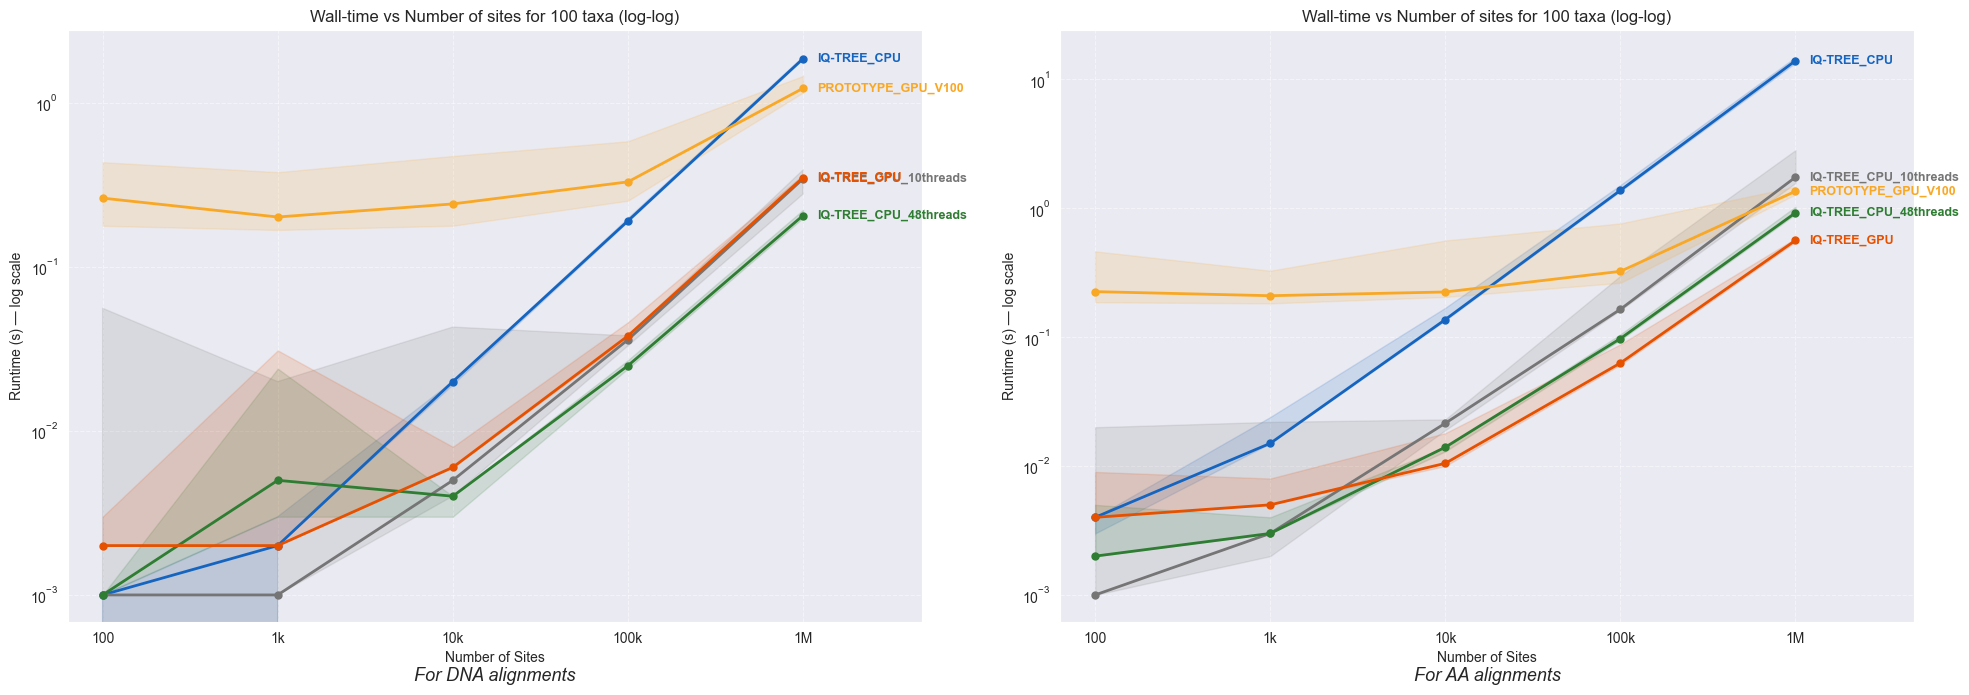

In [12]:
# Side-by-side log-log distribution plot
plot_walltime_sidebyside_logtime(df_dna, df_aa,
    title="Wall-time vs Number of sites for 100 taxa (log-log)",
    path=f"{cwd}/walltime_distribution_sidebyside_logtime.png",
    show_distribution=True)

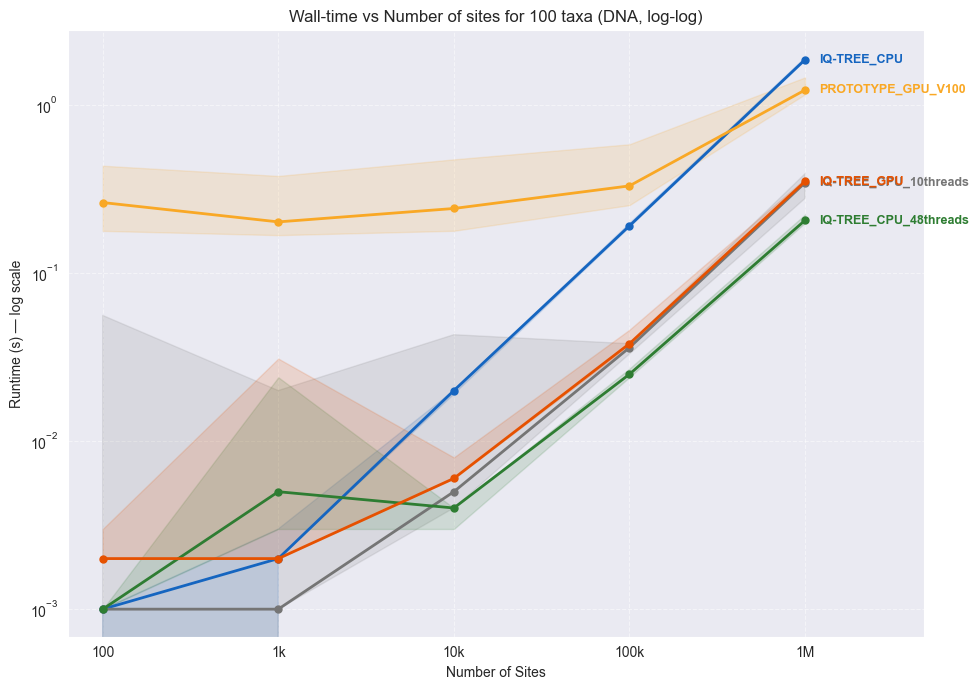

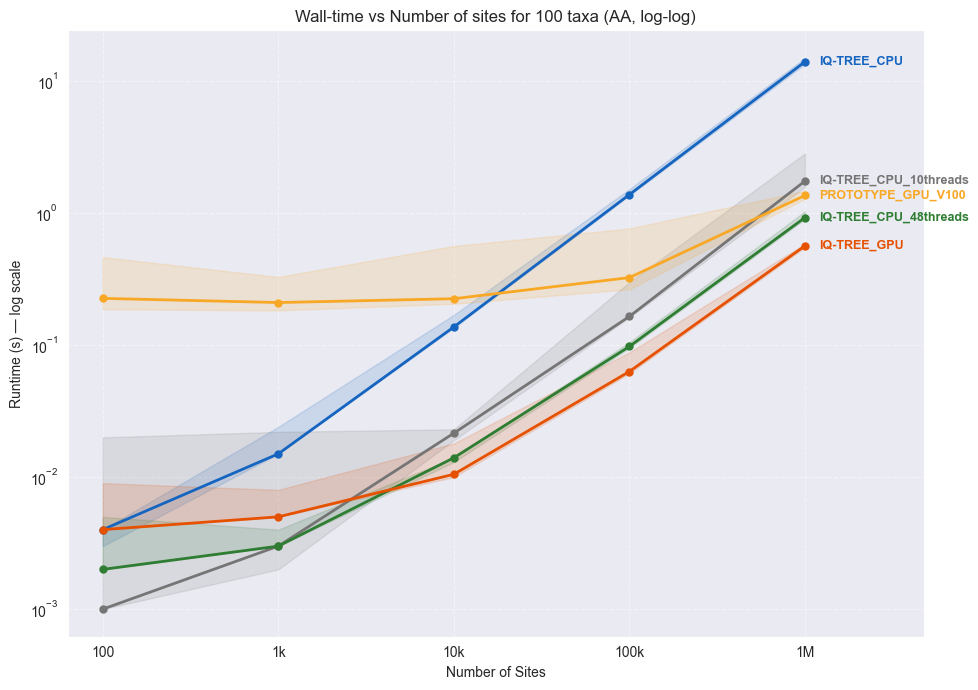

In [13]:
# Individual log-log distribution plots
plot_walltime_single_logtime(df_dna,
    title="Wall-time vs Number of sites for 100 taxa (DNA, log-log)",
    path=f"{cwd}/walltime_dna_distribution_logtime.png",
    show_distribution=True)

plot_walltime_single_logtime(df_aa,
    title="Wall-time vs Number of sites for 100 taxa (AA, log-log)",
    path=f"{cwd}/walltime_aa_distribution_logtime.png",
    show_distribution=True)

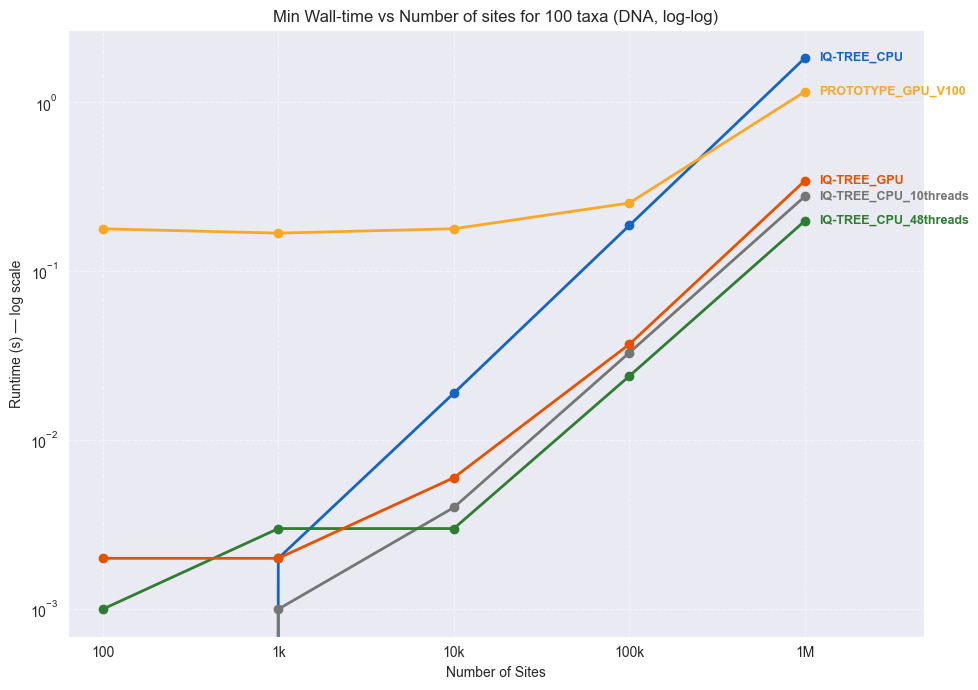

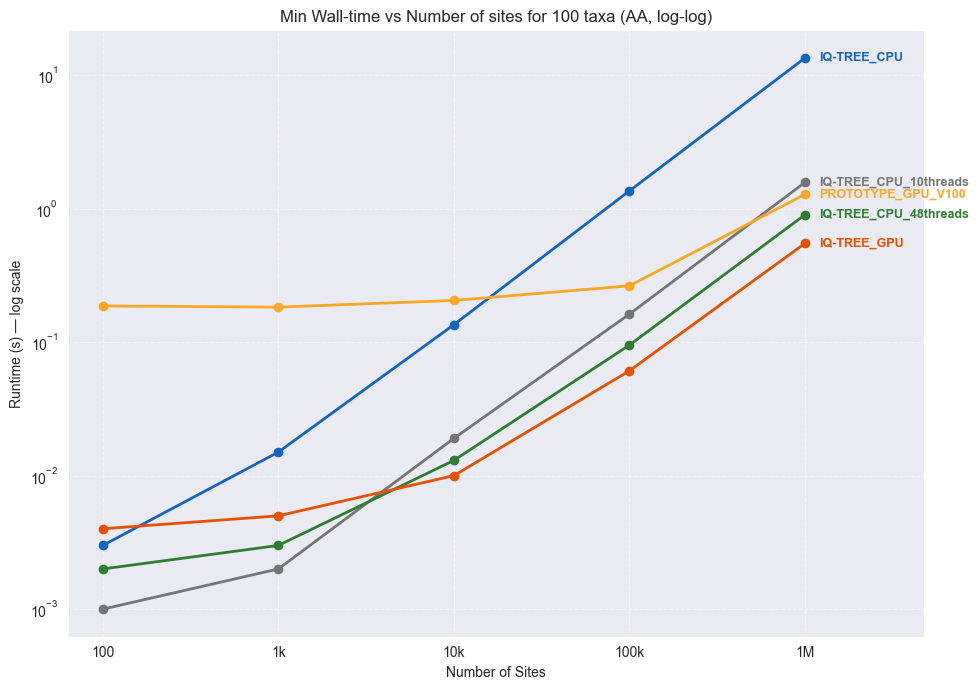

In [14]:
# Min-value log-log plots
plot_min_walltime_logtime(df_dna,
    title="Min Wall-time vs Number of sites for 100 taxa (DNA, log-log)",
    path=f"{cwd}/min_walltime_dna_logtime.png")

plot_min_walltime_logtime(df_aa,
    title="Min Wall-time vs Number of sites for 100 taxa (AA, log-log)",
    path=f"{cwd}/min_walltime_aa_logtime.png")

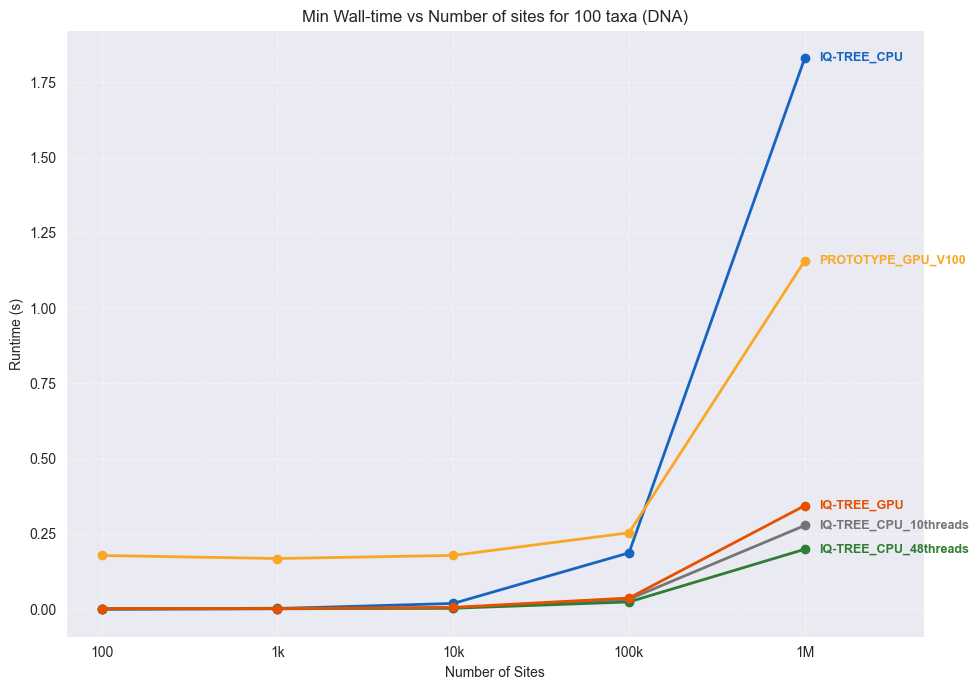

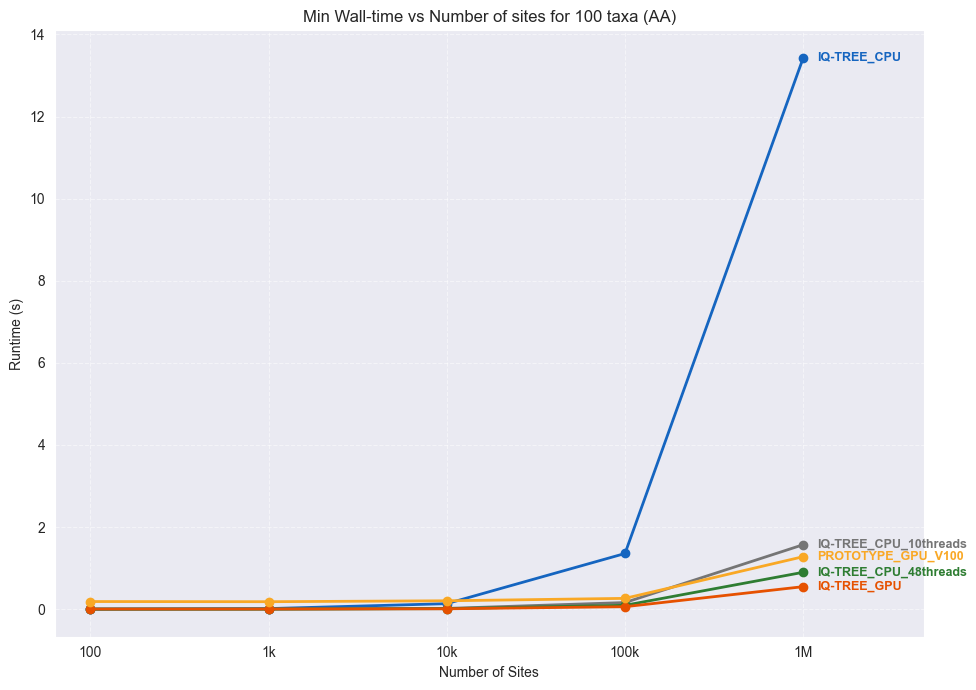

In [15]:
# DNA – min value only
plot_min_walltime(df_dna,
                  title="Min Wall-time vs Number of sites for 100 taxa (DNA)",
                  path=f"{cwd}/min_walltime_dna.png")

# AA – min value only
plot_min_walltime(df_aa,
                  title="Min Wall-time vs Number of sites for 100 taxa (AA)",
                  path=f"{cwd}/min_walltime_aa.png")

# Likelihood Comparison Across Backends

Verify that all backends produce the same log-likelihood values for each alignment size.  
Since IQ-TREE logs round to 3 decimal places while the POC prototype reports full precision,
small apparent differences (~0.001) are expected rounding artifacts, not real numerical divergence.

In [16]:
def likelihood_summary_table(df, title=""):
    """Mean likelihood per backend per site count."""
    tbl = df.groupby(['backend', 'sites'])['likelihood'].mean().unstack()
    tbl.columns = [SITE_LABELS.get(c, str(c)) for c in tbl.columns]
    print(f"=== Mean Log-Likelihood: {title} ===")
    display(tbl.style.format("{:.3f}").set_caption(f"Mean Log-Likelihood per Backend — {title}"))
    return tbl


def likelihood_diff_table(df, ref_backend="IQ-TREE_CPU", title=""):
    """
    Absolute difference of each backend's mean likelihood vs a reference backend.
    A value of 0 means identical; values ~0.001 are IQ-TREE rounding artefacts.
    """
    mean_ll = df.groupby(['backend', 'sites'])['likelihood'].mean().unstack()
    
    if ref_backend not in mean_ll.index:
        print(f"Reference backend '{ref_backend}' not found. Available: {list(mean_ll.index)}")
        return None
    
    ref = mean_ll.loc[ref_backend]
    diff = mean_ll.subtract(ref, axis=1)
    diff.columns = [SITE_LABELS.get(c, str(c)) for c in diff.columns]
    
    print(f"\n=== Absolute Likelihood Difference vs {ref_backend}: {title} ===")
    display(diff.style.format("{:.6f}")
            .set_caption(f"LL difference (backend − {ref_backend}) — {title}")
            .map(lambda v: 'color: green' if v == 0 else ('color: orange' if abs(v) < 0.01 else 'color: red')))
    return diff


def likelihood_std_table(df, title=""):
    """Std-dev of likelihood across 10 runs (should be 0 for deterministic backends)."""
    tbl = df.groupby(['backend', 'sites'])['likelihood'].std().unstack()
    tbl.columns = [SITE_LABELS.get(c, str(c)) for c in tbl.columns]
    print(f"\n=== Likelihood Std-Dev across runs: {title} ===")
    display(tbl.style.format("{:.6f}").set_caption(f"Log-Likelihood Std-Dev — {title}"))
    return tbl

## DNA Likelihood Comparison

In [17]:
likelihood_summary_table(df_dna, title="DNA")
likelihood_diff_table(df_dna, ref_backend="IQ-TREE_CPU", title="DNA")
likelihood_std_table(df_dna, title="DNA");

=== Mean Log-Likelihood: DNA ===


,100,1k,10k,100k,1M
backend,,,,,
IQ-TREE_CPU,-15613.230,-161054.573,-1597939.261,-15983780.144,-159690635.077
IQ-TREE_CPU_10threads,-15613.230,-161054.573,-1597939.261,-15983780.144,-159690635.077
IQ-TREE_CPU_48threads,-15613.230,-161054.573,-1597939.261,-15983780.144,-159690635.077
IQ-TREE_GPU,-15613.230,-161054.573,-1597939.261,-15983780.144,-159690635.077
PROTOTYPE_GPU_V100,-15613.230,-161054.573,-1597939.261,-15983780.144,-159690635.077



=== Absolute Likelihood Difference vs IQ-TREE_CPU: DNA ===


AttributeError: 'Styler' object has no attribute 'map'

## AA Likelihood Comparison

In [ ]:
likelihood_summary_table(df_aa, title="AA")
likelihood_diff_table(df_aa, ref_backend="IQ-TREE_CPU", title="AA")
likelihood_std_table(df_aa, title="AA");

## Likelihood Difference Heatmap (vs IQ-TREE_CPU reference)

In [ ]:
def plot_likelihood_diff_heatmap(df_dna, df_aa, ref_backend="IQ-TREE_CPU", path=""):
    """Side-by-side heatmaps of absolute LL difference vs reference backend."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    
    for ax, df, label in [(ax1, df_dna, "DNA"), (ax2, df_aa, "AA")]:
        mean_ll = df.groupby(['backend', 'sites'])['likelihood'].mean().unstack()
        ref = mean_ll.loc[ref_backend]
        diff = mean_ll.subtract(ref, axis=1).abs()
        diff.columns = [SITE_LABELS.get(c, str(c)) for c in diff.columns]
        
        sns.heatmap(diff, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax,
                    linewidths=0.5, cbar_kws={'label': '|LL difference|'})
        ax.set_title(f"{label} — |LL diff| vs {ref_backend}")
        ax.set_ylabel("Backend")
        ax.set_xlabel("Alignment Length")
    
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()

import seaborn as sns
plot_likelihood_diff_heatmap(df_dna, df_aa, path=f"{cwd}/likelihood_diff_heatmap.png")